# Exploração do faturamento líquido

Começando a análise. O objetivo é revelar padrões de faturamento líquido que ajudem o time técnico a validar a fonte e a diretoria a priorizar discussões comerciais. Cada linha representa um item de pedido.

## A fonte foi lida corretamente?

Antes de comparar resultados, verificamos dimensão, rótulos, tipos e uma amostra da base.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.options.display.float_format = '{:,.2f}'.format
raiz = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'data' / 'train.csv').exists())
df = pd.read_csv(raiz / 'data' / 'train.csv')
df.shape, df.head(3)

((9800, 18),
    Row ID        Order ID  Order Date   Ship Date     Ship Mode Customer ID  \
 0       1  CA-2017-152156  08/11/2017  11/11/2017  Second Class    CG-12520   
 1       2  CA-2017-152156  08/11/2017  11/11/2017  Second Class    CG-12520   
 2       3  CA-2017-138688  12/06/2017  16/06/2017  Second Class    DV-13045   
 
      Customer Name    Segment        Country         City       State  \
 0      Claire Gute   Consumer  United States    Henderson    Kentucky   
 1      Claire Gute   Consumer  United States    Henderson    Kentucky   
 2  Darrin Van Huff  Corporate  United States  Los Angeles  California   
 
    Postal Code Region       Product ID         Category Sub-Category  \
 0    42,420.00  South  FUR-BO-10001798        Furniture    Bookcases   
 1    42,420.00  South  FUR-CH-10000454        Furniture       Chairs   
 2    90,036.00   West  OFF-LA-10000240  Office Supplies       Labels   
 
                                         Product Name  Sales  
 0        

## Os campos e os valores estão prontos para análise?

A checagem identifica tipos que precisam de conversão e campos com cobertura incompleta.

In [2]:
tipos = df.dtypes.astype(str).to_frame('tipo')
ausentes = df.isna().sum().to_frame('ausentes')
ausentes = ausentes.loc[ausentes['ausentes'].gt(0)]
tipos, ausentes

(                  tipo
 Row ID           int64
 Order ID           str
 Order Date         str
 Ship Date          str
 Ship Mode          str
 Customer ID        str
 Customer Name      str
 Segment            str
 Country            str
 City               str
 State              str
 Postal Code    float64
 Region             str
 Product ID         str
 Category           str
 Sub-Category       str
 Product Name       str
 Sales          float64,
              ausentes
 Postal Code        11)

## As datas representam o período esperado?

As datas serão interpretadas como dia/mês/ano. A prévia abaixo confirma a transformação antes de usá-la nos indicadores.

In [3]:
df = df.copy()
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True)
df[['Order Date', 'Ship Date', 'Sales']].head(3)

,Order Date,Ship Date,Sales
0,2017-11-08,2017-11-11,261.96
1,2017-11-08,2017-11-11,731.94
2,2017-06-12,2017-06-16,14.62


In [4]:
periodo = pd.DataFrame({
    'início': [df['Order Date'].min()],
    'fim': [df['Order Date'].max()],
    'linhas': [len(df)],
    'pedidos únicos': [df['Order ID'].nunique()]
})
periodo

,início,fim,linhas,pedidos únicos
0,2015-01-03,2018-12-30,9800,4922


## A base tem restrições que mudam a leitura dos resultados?

Verificamos duplicidades e a cobertura de código postal. O campo geográfico será usado apenas onde estiver preenchido, sem imputar localidades.

In [5]:
qualidade = pd.DataFrame({
    'linhas duplicadas': [df.duplicated().sum()],
    'códigos postais ausentes': [df['Postal Code'].isna().sum()],
    'participação ausente': [df['Postal Code'].isna().mean()]
})
qualidade

,linhas duplicadas,códigos postais ausentes,participação ausente
0,0,11,0.00


## Qual é a escala comercial do período?

O faturamento líquido total, os pedidos e o ticket por pedido definem a referência para todas as comparações seguintes.

In [6]:
faturamento = df['Sales'].sum()
pedidos = df['Order ID'].nunique()
kpis = pd.DataFrame({
    'faturamento líquido': [faturamento],
    'pedidos': [pedidos],
    'ticket médio por pedido': [faturamento / pedidos]
})
kpis

,faturamento líquido,pedidos,ticket médio por pedido
0,"2,261,536.78",4922,459.48


**Leitura da qualidade:** não há linhas duplicadas. Os 11 CEPs ausentes representam cerca de `0,1%` dos itens e não impedem a análise regional já presente na fonte; ainda assim, não serão usados para inferir localidades.

**Leitura da escala:** o período reúne `2,26 milhões` de faturamento líquido em 4.922 pedidos. O ticket médio de `459,48` é uma referência de faturamento por pedido, não uma medida de lucratividade, pois a fonte não contém custos, descontos ou margem.

## Quais categorias concentram o faturamento líquido?

Vamos comparar faturamento, pedidos e ticket por categoria para distinguir tamanho comercial de valor médio por pedido.

In [7]:
categorias = df.groupby('Category').agg(
    faturamento=('Sales', 'sum'),
    pedidos=('Order ID', 'nunique')
).sort_values('faturamento', ascending=False)
categorias['ticket por pedido'] = categorias['faturamento'] / categorias['pedidos']
categorias['participação'] = categorias['faturamento'] / faturamento
categorias

,faturamento,pedidos,ticket por pedido,participação
Category,,,,
Technology,"827,455.87",1519,544.74,0.37
Furniture,"728,658.58",1727,421.92,0.32
Office Supplies,"705,422.33",3676,191.90,0.31


## A categoria líder sustenta a maior receita do período?

O gráfico evidencia a concentração do faturamento líquido por categoria entre 2015 e 2018.

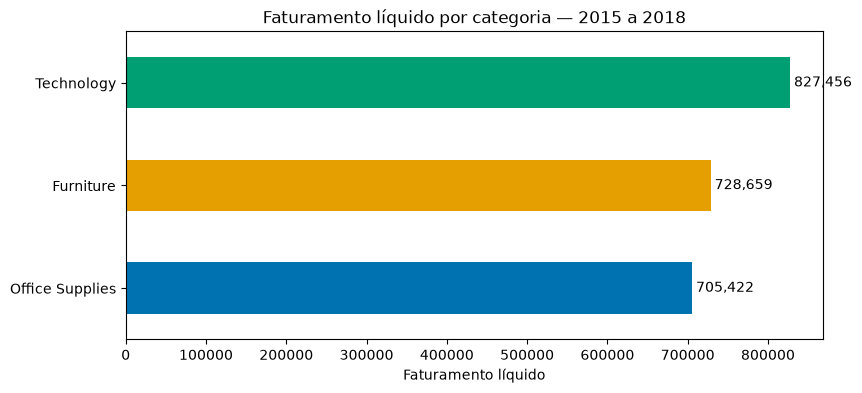

In [8]:
cores = ['#0072B2', '#E69F00', '#009E73']
ax = categorias['faturamento'].sort_values().plot.barh(color=cores, figsize=(9, 4))
ax.set(title='Faturamento líquido por categoria — 2015 a 2018', xlabel='Faturamento líquido', ylabel='')
ax.grid(False)
for barra in ax.patches:
    ax.text(barra.get_width(), barra.get_y() + barra.get_height() / 2, f' {barra.get_width():,.0f}', va='center')
plt.show()

**Leitura por categoria:** Tecnologia reúne `37%` do faturamento líquido e tem o maior ticket por pedido. Suprimentos de Escritório possui o maior número de pedidos, mas o menor ticket. Isso aponta perfis comerciais distintos; não permite concluir qual categoria é mais rentável.

## O faturamento está crescendo ao longo dos anos?

Comparamos faturamento e pedidos por ano para separar aumento de receita de simples variação no volume de pedidos.

In [9]:
df['Ano'] = df['Order Date'].dt.year
df[['Order Date', 'Ano', 'Sales']].head(3)

,Order Date,Ano,Sales
0,2017-11-08,2017,261.96
1,2017-11-08,2017,731.94
2,2017-06-12,2017,14.62


In [10]:
anuais = df.groupby('Ano').agg(
    faturamento=('Sales', 'sum'),
    pedidos=('Order ID', 'nunique')
).sort_index()
anuais['ticket por pedido'] = anuais['faturamento'] / anuais['pedidos']
anuais['variação anual'] = anuais['faturamento'].pct_change()
anuais

,faturamento,pedidos,ticket por pedido,variação anual
Ano,,,,
2015,"479,856.21",947,506.71,NaN
2016,"459,436.01",1019,450.87,-0.04
2017,"600,192.55",1295,463.47,0.31
2018,"722,052.02",1661,434.71,0.20


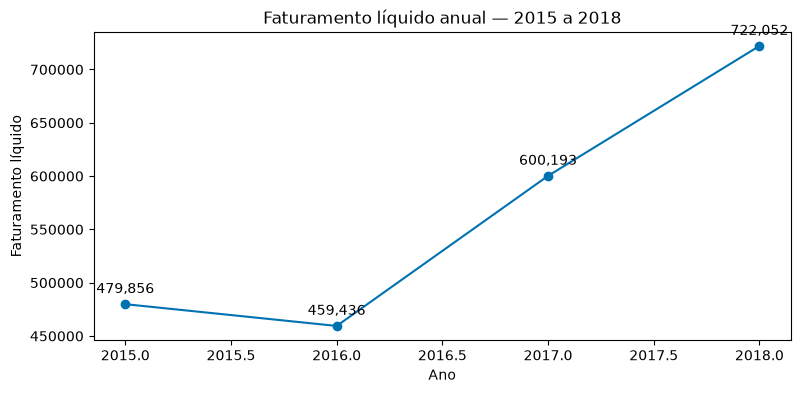

In [11]:
ax = anuais['faturamento'].plot(marker='o', color='#0072B2', figsize=(9, 4))
ax.set(title='Faturamento líquido anual — 2015 a 2018', xlabel='Ano', ylabel='Faturamento líquido')
ax.grid(False)
for ano, valor in anuais['faturamento'].items():
    ax.annotate(f'{valor:,.0f}', (ano, valor), xytext=(0, 8), textcoords='offset points', ha='center')
plt.show()

**Leitura temporal:** a queda de faturamento em 2016 ocorreu mesmo com mais pedidos, acompanhando redução do ticket médio. O crescimento posterior recuperou a receita, mas o ticket de 2018 continua abaixo do nível de 2015. Os dados mostram associação, não a causa dessa mudança.

## Quais regiões sustentam a maior parte do faturamento?

A comparação reúne faturamento, pedidos e ticket por região para evitar priorizar uma região apenas pelo seu tamanho.

In [12]:
regioes = df.groupby('Region').agg(
    faturamento=('Sales', 'sum'),
    pedidos=('Order ID', 'nunique')
).sort_values('faturamento', ascending=False)
regioes['ticket por pedido'] = regioes['faturamento'] / regioes['pedidos']
regioes['participação'] = regioes['faturamento'] / faturamento
regioes

,faturamento,pedidos,ticket por pedido,participação
Region,,,,
West,"710,219.68",1587,447.52,0.31
East,"669,518.73",1369,489.06,0.30
Central,"492,646.91",1156,426.17,0.22
South,"389,151.46",810,480.43,0.17


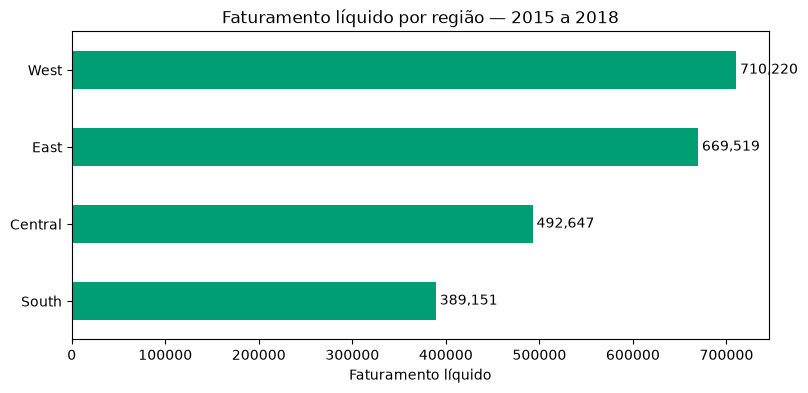

In [13]:
ax = regioes['faturamento'].sort_values().plot.barh(color='#009E73', figsize=(9, 4))
ax.set(title='Faturamento líquido por região — 2015 a 2018', xlabel='Faturamento líquido', ylabel='')
ax.grid(False)
for barra in ax.patches:
    ax.text(barra.get_width(), barra.get_y() + barra.get_height() / 2, f' {barra.get_width():,.0f}', va='center')
plt.show()

**Leitura regional:** Oeste lidera em faturamento e pedidos, enquanto Leste apresenta o maior ticket por pedido. A diferença de receita entre as duas é pequena; sem custos ou margem, não é possível concluir qual região gera melhor resultado econômico.

## Quais subcategorias merecem investigação prioritária?

O ranking mostra quais grupos de produtos concentram a maior parcela do faturamento líquido e devem ser o ponto de partida para análises de preço, estoque e margem.

In [14]:
subcategorias = df.groupby('Sub-Category').agg(
    faturamento=('Sales', 'sum'),
    pedidos=('Order ID', 'nunique')
).sort_values('faturamento', ascending=False)
subcategorias['participação'] = subcategorias['faturamento'] / faturamento
subcategorias.head(7)

,faturamento,pedidos,participação
Sub-Category,,,
Phones,"327,782.45",803,0.14
Chairs,"322,822.73",566,0.14
Storage,"219,343.39",764,0.10
Tables,"202,810.63",302,0.09
Binders,"200,028.79",1291,0.09
Machines,"189,238.63",112,0.08
Accessories,"164,186.70",702,0.07


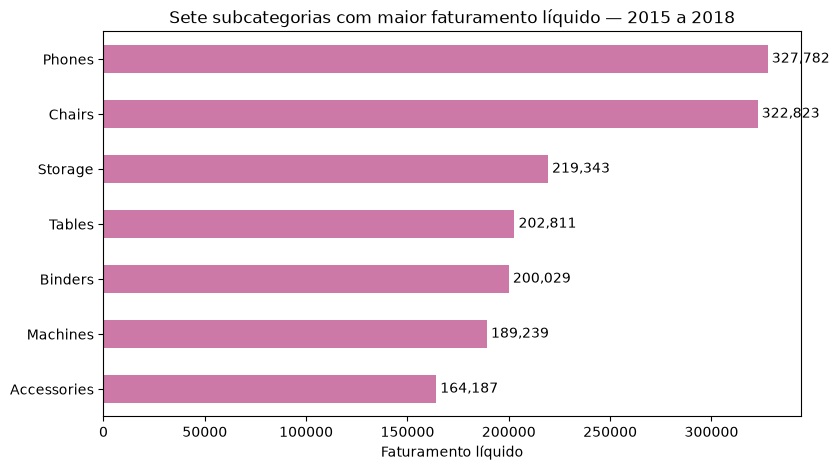

In [15]:
top_subcategorias = subcategorias.head(7).sort_values('faturamento')
ax = top_subcategorias['faturamento'].plot.barh(color='#CC79A7', figsize=(9, 5))
ax.set(title='Sete subcategorias com maior faturamento líquido — 2015 a 2018', xlabel='Faturamento líquido', ylabel='')
ax.grid(False)
for barra in ax.patches:
    ax.text(barra.get_width(), barra.get_y() + barra.get_height() / 2, f' {barra.get_width():,.0f}', va='center')
plt.show()

**Leitura de portfólio:** Phones e Chairs são as duas maiores subcategorias, cada uma próxima de `14%` do faturamento. Machines participa com `8%` da receita em apenas 112 pedidos, indicando itens de maior valor médio que merecem validação de preço, desconto e margem antes de se tornarem prioridade comercial.

## Síntese para decisão

### Achados
- A fonte contém 9.800 itens de 4.922 pedidos, sem duplicidades; os 11 CEPs ausentes são uma limitação pontual.
- O faturamento líquido acumulado é de `2,26 milhões`, com ticket médio por pedido de `459,48`.
- Tecnologia concentra `37%` da receita e apresenta o maior ticket por pedido; isso não equivale a maior margem.
- O faturamento caiu em 2016 apesar de mais pedidos, junto com queda de ticket; em 2018 alcançou o pico de receita, ainda com ticket inferior ao de 2015.
- Oeste lidera em faturamento e pedidos; Leste tem ticket médio mais alto e receita próxima.
- Phones, Chairs e Machines são pontos prioritários para detalhar preço, desconto, disponibilidade e margem.

### Limitações e próximas decisões
- A fonte não traz custo, lucro, margem, desconto, quantidade ou metas; não permite recomendar corte, expansão ou investimento com base em rentabilidade.
- Integrar margem, desconto, estoque e devoluções por item permitirá priorizar categorias de forma econômica, não apenas por faturamento.
- Investigar o mix de pedidos e produtos em 2016 explica melhor a queda de ticket; comparar Leste e Oeste por subcategoria ajuda a transformar o achado regional em ação.